Number of CSV files found: 645

RESULTS
Missing columns: 1147
Corrupted columns: 372
Clean columns: 3903
Total columns checked: 5422

PERCENTAGES
Missing   : 21.15%
Corrupted : 6.86%
Clean     : 71.98%


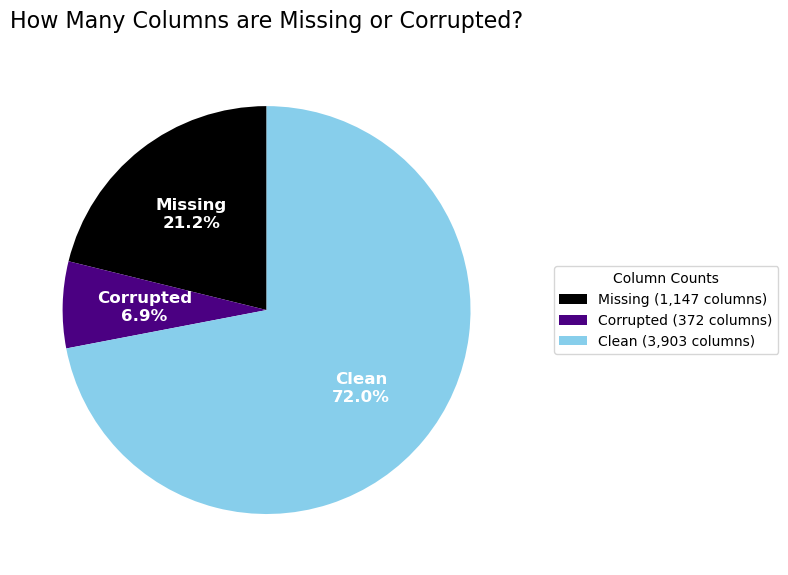

In [20]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt

missing_count = 0
corrupted_count = 0
clean_count = 0

# Search ALL folders beneath current directory
csv_files = glob.glob("/home/jovyan/Current Classes/CSCI 5612/The_NFL_Project_MachineLearningClass/Data_Raw/**/*.csv", recursive=True)

print("Number of CSV files found:", len(csv_files))


for filename in csv_files:
    
    df = pd.read_csv(filename, dtype=str)

    # Skip the leftmost column, those are the playernames
    for col in df.columns[1:]:

        values = df[col].fillna("").astype(str).str.strip()

        # Remove "--" and blanks
        numeric_values = []

        for v in values:
            if v == "" or v == "--":
                continue

            try:
                numeric_values.append(float(v))
            except:
                pass

        # CASE 1) Missing column data
        if len(numeric_values) == 0:
            missing_count += 1
            continue

        # CASE 2) Corrupted column data
        nonzero_count = sum(x != 0 for x in numeric_values)
        proportion_nonzero = nonzero_count / len(numeric_values)

        if proportion_nonzero < 0.07:
            corrupted_count += 1
        else:
            clean_count += 1

print("\nRESULTS")
print("Missing columns:", missing_count)
print("Corrupted columns:", corrupted_count)
print("Clean columns:", clean_count)
print("Total columns checked:", missing_count + corrupted_count + clean_count)


## Now it's time to graph it all


total = missing_count + corrupted_count + clean_count

missing_pct = 100 * missing_count / total
corrupted_pct = 100 * corrupted_count / total
clean_pct = 100 * clean_count / total

print("\nPERCENTAGES")
print(f"Missing   : {missing_pct:.2f}%")
print(f"Corrupted : {corrupted_pct:.2f}%")
print(f"Clean     : {clean_pct:.2f}%")

labels = ['Missing', 'Corrupted', 'Clean']
sizes = [missing_count, corrupted_count, clean_count]
colors = ['black','#4B0082','skyblue']

# Custom label function
def make_autopct(labels):
    def my_autopct(pct):
        my_autopct.counter += 1
        label = labels[my_autopct.counter - 1]
        return f'{label}\n{pct:.1f}%'

    my_autopct.counter = 0
    return my_autopct

plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    sizes,
    labels=None,
    colors=colors,
    autopct=make_autopct(labels),
    startangle=90,
    textprops={
        'color': 'white',
        'fontsize': 12
    }
)

# Make slice text bold
for autotext in autotexts:
    autotext.set_fontweight('bold')

# Legend with actual counts
plt.legend(
    wedges,
    [
        f"Missing ({missing_count:,} columns)",
        f"Corrupted ({corrupted_count:,} columns)",
        f"Clean ({clean_count:,} columns)"
    ],
    title="Column Counts",
    loc="center left",
    bbox_to_anchor=(1.05, 0.5)
)

plt.title(
    "How Many Columns are Missing or Corrupted?",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    "Data_Quality_Pie_Chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()